# Texte -> image: benchmark production

Objectif: comparer les strategies locales open source pour la recherche texte -> image et retenir une approche maintenable pour le produit.

Decision actuelle: ne pas faire de vector-only. On garde des canaux separes et on fusionne tardivement: metadata, BM25, OpenCLIP text->image, OpenCLIP text->caption, RRF, puis reranking local optionnel sur top-N.

## Architecture cible

```text
query text
-> metadata filters
-> BM25 captions/tags
-> OpenCLIP text -> image vectors
-> OpenCLIP text -> caption vectors
-> RRF late fusion
-> optional local reranker top-N
-> results
```

Le LLM juge reste utile pour evaluer ou reranker 20-50 candidats, pas pour faire le rappel primaire.

In [1]:
from pathlib import Path
import json
import os
import subprocess
import sys

ROOT = Path.cwd()
while ROOT.name != 'photo-ai-platform' and ROOT.parent != ROOT:
    ROOT = ROOT.parent

BENCHMARK = ROOT / 'ml' / 'experiments' / 'artifact_benchmark.py'
REPORT = ROOT / 'reports' / 'algorithm_tests' / 'latest' / 'summary.json'
BENCHMARK.exists(), REPORT


(True,
 WindowsPath('c:/Users/choun/OneDrive - Groupe INSEEC (POCE)/Bureau/projet-ia/photo-ai-platform/reports/algorithm_tests/latest/summary.json'))

## Lancer le benchmark complet

Cette cellule execute le meme benchmark que le pipeline local. Elle teste les requetes complexes definies dans `artifact_benchmark.py` sur les 5000 images alignees avec les captions et embeddings caches.

In [2]:
cmd = [sys.executable, str(BENCHMARK), '--top-k', '10', '--text-batch-size', '8']
env = os.environ.copy()
env.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')
env.setdefault('OMP_NUM_THREADS', '1')
env.setdefault('MKL_NUM_THREADS', '1')

result = subprocess.run(cmd, cwd=ROOT, text=True, capture_output=True, env=env)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError(f'Benchmark failed with exit code {result.returncode}')


Dataset: 5000 images
Report: reports\algorithm_tests\latest\summary.json
Text->image: {'caption_bm25': {'precision_at_k': 0.9175}, 'caption_tfidf': {'precision_at_k': 0.9025}, 'bm25_seed_caption_expansion': {'precision_at_k': 0.86}, 'bm25_seed_image_expansion': {'precision_at_k': 0.7025}, 'linear_bm25_caption': {'precision_at_k': 0.9175}, 'linear_bm25_image': {'precision_at_k': 0.9125}, 'linear_all_channels': {'precision_at_k': 0.9175}, 'rrf_bm25_caption': {'precision_at_k': 0.91}, 'rrf_bm25_image': {'precision_at_k': 0.9025}, 'rrf_all_channels': {'precision_at_k': 0.915}, 'two_stage_bm25_recall_image_rerank': {'precision_at_k': 0.91}, 'two_stage_image_recall_bm25_rerank': {'precision_at_k': 0.9175}, 'separate_bm25_image_interleave': {'precision_at_k': 0.835}, 'openclip_text_to_image': {'precision_at_k': 0.7175}, 'openclip_text_to_caption': {'precision_at_k': 0.8125}, 'linear_openclip_bm25': {'precision_at_k': 0.9125}, 'linear_openclip_caption_bm25': {'precision_at_k': 0.9175}, 'rrf_op

In [3]:
summary = json.loads(REPORT.read_text(encoding='utf-8'))
summary['dataset'], summary['text_encoder']


({'images': 5000,
  'data_dir': 'notebooks\\data\\images\\val2017',
  'artifacts_dir': 'notebooks\\data\\artifacts',
  'mapping_note': "excluded local '- Copie' files to match cached artifact count"},
 {'enabled': True,
  'library': 'open_clip',
  'model': 'ViT-L-14',
  'pretrained': 'openai',
  'device': 'cpu',
  'embedding_dim': 768,
  'elapsed_seconds': 129.96})

In [4]:
metrics = summary['text_to_image']['metrics']
ranked = sorted(metrics.items(), key=lambda item: item[1]['precision_at_k'], reverse=True)
ranked[:12]


[('caption_bm25', {'precision_at_k': 0.9175}),
 ('linear_bm25_caption', {'precision_at_k': 0.9175}),
 ('linear_all_channels', {'precision_at_k': 0.9175}),
 ('two_stage_image_recall_bm25_rerank', {'precision_at_k': 0.9175}),
 ('linear_openclip_caption_bm25', {'precision_at_k': 0.9175}),
 ('rrf_all_channels', {'precision_at_k': 0.915}),
 ('linear_bm25_image', {'precision_at_k': 0.9125}),
 ('linear_openclip_bm25', {'precision_at_k': 0.9125}),
 ('two_stage_bm25_recall_openclip_rerank', {'precision_at_k': 0.9125}),
 ('rrf_bm25_caption', {'precision_at_k': 0.91}),
 ('two_stage_bm25_recall_image_rerank', {'precision_at_k': 0.91}),
 ('two_stage_openclip_recall_bm25_rerank', {'precision_at_k': 0.905})]

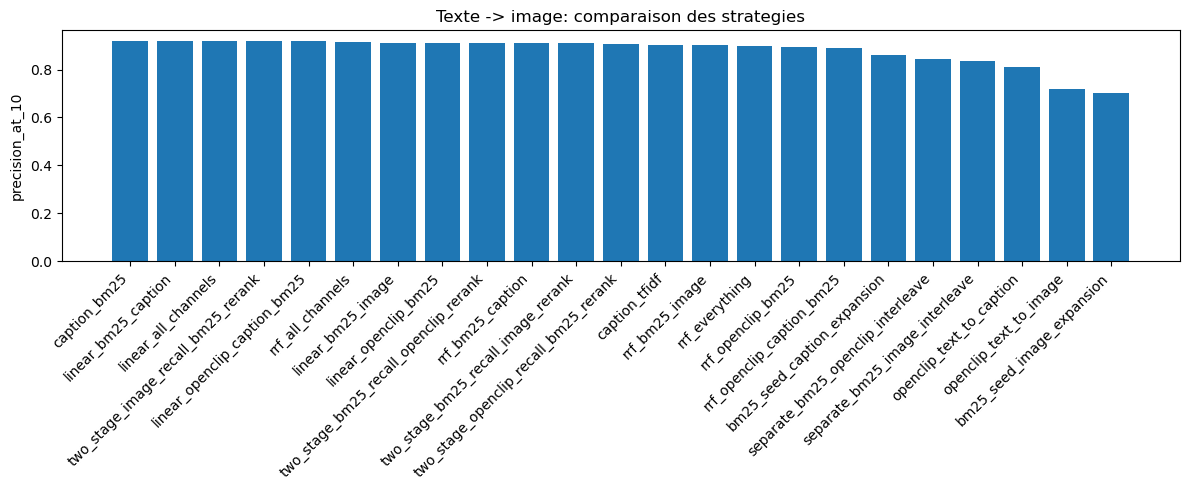

In [5]:
try:
    import matplotlib.pyplot as plt
    labels = [name for name, _ in ranked]
    values = [row['precision_at_k'] for _, row in ranked]
    plt.figure(figsize=(12, 5))
    plt.bar(labels, values)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('precision_at_10')
    plt.title('Texte -> image: comparaison des strategies')
    plt.tight_layout()
    plt.show()
except ImportError:
    print('matplotlib non installe; afficher ranked directement.')


## Prompts denses et faux positifs

Cette section teste le cas le plus dangereux en produit: un utilisateur donne une requete longue avec des contraintes positives et negatives. Exemple: `person riding a horse outdoors without cars or motorcycles`.

On compare le ranking brut avec des variantes qui penalisent ou filtrent les faux positifs, dont `contrastive_negative_rerank` qui encode separement les concepts positifs et negatifs.

In [6]:
dense_metrics = summary['dense_text_to_image']['metrics']
dense_ranked = sorted(
    dense_metrics.items(),
    key=lambda item: (item[1]['false_positive_rate_at_k'], -item[1]['constraint_precision_at_k']),
)
dense_ranked


[('constraint_aware_rerank',
  {'constraint_precision_at_k': 0.9256,
   'false_positive_rate_at_k': 0.0,
   'avg_positive_coverage_at_k': 0.7669}),
 ('hard_negative_filter',
  {'constraint_precision_at_k': 0.9256,
   'false_positive_rate_at_k': 0.0,
   'avg_positive_coverage_at_k': 0.7669}),
 ('rrf_constraint_aware',
  {'constraint_precision_at_k': 0.8872,
   'false_positive_rate_at_k': 0.0,
   'avg_positive_coverage_at_k': 0.7297}),
 ('contrastive_negative_rerank',
  {'constraint_precision_at_k': 0.8692,
   'false_positive_rate_at_k': 0.0,
   'avg_positive_coverage_at_k': 0.7286}),
 ('openclip_text_to_caption',
  {'constraint_precision_at_k': 0.7436,
   'false_positive_rate_at_k': 0.0436,
   'avg_positive_coverage_at_k': 0.6521}),
 ('openclip_text_to_image',
  {'constraint_precision_at_k': 0.5436,
   'false_positive_rate_at_k': 0.0974,
   'avg_positive_coverage_at_k': 0.4971}),
 ('raw_hybrid',
  {'constraint_precision_at_k': 0.7872,
   'false_positive_rate_at_k': 0.1231,
   'avg_posit

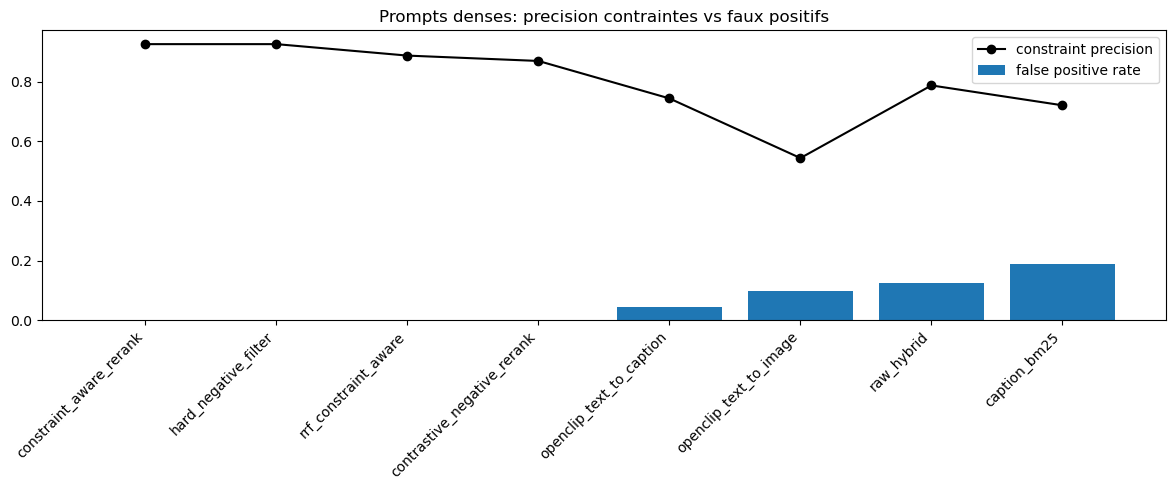

In [7]:
try:
    import matplotlib.pyplot as plt
    labels = [name for name, _ in dense_ranked]
    fp = [row['false_positive_rate_at_k'] for _, row in dense_ranked]
    cp = [row['constraint_precision_at_k'] for _, row in dense_ranked]
    plt.figure(figsize=(12, 5))
    plt.bar(labels, fp, label='false positive rate')
    plt.plot(labels, cp, marker='o', color='black', label='constraint precision')
    plt.xticks(rotation=45, ha='right')
    plt.title('Prompts denses: precision contraintes vs faux positifs')
    plt.legend()
    plt.tight_layout()
    plt.show()
except ImportError:
    print('matplotlib non installe; afficher dense_ranked directement.')


## Diagnostic step-by-step

Cette section montre le chemin de decision pour un prompt dense. Elle sert a verifier la coherence, les faux positifs, les contraintes manquantes et les points bloquants image par image.

Change `DENSE_QUERY_INDEX` pour inspecter un autre prompt du benchmark.

In [8]:
from IPython.display import Image as DisplayImage, display
import pandas as pd

DENSE_QUERY_INDEX = 0
dense_query = summary['dense_text_to_image']['queries'][DENSE_QUERY_INDEX]
{
    'query': dense_query['query'],
    'positive_constraints': dense_query['positive_constraints'],
    'negative_constraints': dense_query['negative_constraints'],
    'risk_flags': dense_query.get('risk_flags', []),
}


{'query': 'person riding a horse outdoors without cars or motorcycles',
 'positive_constraints': ['person', 'riding', 'horse', 'outdoor'],
 'negative_constraints': ['car', 'motorcycle'],
 'risk_flags': ['raw_hybrid_contains_explicit_negative_constraints']}

In [9]:
stage_rows = []
for step in dense_query['step_by_step']:
    metrics = step.get('metrics', {})
    stage_rows.append({
        'stage': step['stage'],
        'constraint_precision_at_k': metrics.get('constraint_precision_at_k'),
        'false_positive_rate_at_k': metrics.get('false_positive_rate_at_k'),
        'avg_positive_coverage_at_k': metrics.get('avg_positive_coverage_at_k'),
        'negative_hits_in_top_k': step['negative_hits_in_top_k'],
        'complete_constraint_matches': step['complete_constraint_matches'],
        'avg_positive_coverage': step['avg_positive_coverage'],
        'removed_from_previous': step['removed_from_previous'],
        'introduced_vs_previous': step['introduced_vs_previous'],
    })
pd.DataFrame(stage_rows)


,stage,constraint_precision_at_k,false_positive_rate_at_k,avg_positive_coverage_at_k,negative_hits_in_top_k,complete_constraint_matches,avg_positive_coverage,removed_from_previous,introduced_vs_previous
0,caption_bm25,0.5,0.5,0.700,5,2,0.700,[],"[3926, 4971, 3915, 271, 366, 1557, 2124, 3796,..."
1,raw_hybrid,0.8,0.2,0.750,2,2,0.750,"[1557, 78, 1419]","[4935, 674, 224]"
2,constraint_aware_rerank,1.0,0.0,0.825,0,3,0.825,"[3926, 4971]","[2377, 4952]"
3,hard_negative_filter,1.0,0.0,0.825,0,3,0.825,[],[]
4,rrf_constraint_aware,1.0,0.0,0.850,0,4,0.850,"[271, 366]","[3310, 4260]"
5,contrastive_negative_rerank,1.0,0.0,0.850,0,4,0.850,"[224, 3310, 4260]","[399, 366, 72]"
6,openclip_text_to_image,0.8,0.0,0.600,0,1,0.600,"[2124, 399, 366, 3796, 2377, 72, 4952]","[224, 4260, 3072, 2627, 1981, 753, 4124]"
7,openclip_text_to_caption,1.0,0.0,0.800,0,2,0.800,"[4260, 3072, 2627, 1981, 753, 4124]","[366, 271, 2124, 3796, 3310, 72]"


In [10]:
def diagnostic_rows(items):
    rows = []
    for item in items:
        diag = item['diagnostics']
        scores = item.get('scores', {})
        rows.append({
            'stage': item.get('stage'),
            'rank': item.get('rank'),
            'index': item['index'],
            'filename': item['filename'],
            'caption': item['caption'],
            'positive_hits': ', '.join(diag['positive_hits']),
            'missing_positive': ', '.join(diag['missing_positive']),
            'negative_hits': ', '.join(diag['negative_hits']),
            'blockers': ', '.join(diag['blockers']),
            'positive_coverage': diag['positive_coverage'],
            'raw_hybrid': scores.get('raw_hybrid'),
            'constraint_score': scores.get('constraint_score'),
            'negative_penalty': scores.get('negative_penalty'),
            'contrastive_negative_score': scores.get('contrastive_negative_score'),
        })
    return pd.DataFrame(rows)

diagnostic_rows(dense_query['raw_hybrid_blockers'])


,stage,rank,index,filename,caption,positive_hits,missing_positive,negative_hits,blockers,positive_coverage,raw_hybrid,constraint_score,negative_penalty,contrastive_negative_score
0,raw_hybrid,1,3915,000000454798.jpg,a person riding a horse,"person, riding, horse",outdoor,,missing_positive_constraints,0.75,0.9671,0.9375,0.0,0.4595
1,raw_hybrid,2,271,000000029187.jpg,a person riding a horse,"person, riding, horse",outdoor,,missing_positive_constraints,0.75,0.9268,0.9042,0.0,0.3472
2,raw_hybrid,3,366,000000040036.jpg,a person riding a horse,"person, riding, horse",outdoor,,missing_positive_constraints,0.75,0.9243,0.9021,0.0,0.4384
3,raw_hybrid,6,4935,000000574297.jpg,a man riding a horse,"person, riding, horse",outdoor,,missing_positive_constraints,0.75,0.8483,0.8391,0.0,0.4139
4,raw_hybrid,7,674,000000079229.jpg,a man riding a horse,"person, riding, horse",outdoor,,missing_positive_constraints,0.75,0.8439,0.8355,0.0,0.4229
5,raw_hybrid,8,224,000000023126.jpg,a man riding a horse,"person, riding, horse",outdoor,,missing_positive_constraints,0.75,0.8430,0.8347,0.0,0.3933
6,raw_hybrid,9,3926,000000455624.jpg,a person riding a motorcycle,"person, riding","horse, outdoor",motorcycle,"negative_constraint_hit, missing_positive_cons...",0.50,0.8413,0.3458,0.5,-0.0105
7,raw_hybrid,10,4971,000000578792.jpg,a person riding a motorcycle,"person, riding","horse, outdoor",motorcycle,"negative_constraint_hit, missing_positive_cons...",0.50,0.8377,0.3428,0.5,-0.0188


In [11]:
STAGE = 'raw_hybrid'
stage = next(step for step in dense_query['step_by_step'] if step['stage'] == STAGE)
diagnostic_rows(stage['items'])


,stage,rank,index,filename,caption,positive_hits,missing_positive,negative_hits,blockers,positive_coverage,raw_hybrid,constraint_score,negative_penalty,contrastive_negative_score
0,raw_hybrid,1,3915,000000454798.jpg,a person riding a horse,"person, riding, horse",outdoor,,missing_positive_constraints,0.75,0.9671,0.9375,0.0,0.4595
1,raw_hybrid,2,271,000000029187.jpg,a person riding a horse,"person, riding, horse",outdoor,,missing_positive_constraints,0.75,0.9268,0.9042,0.0,0.3472
2,raw_hybrid,3,366,000000040036.jpg,a person riding a horse,"person, riding, horse",outdoor,,missing_positive_constraints,0.75,0.9243,0.9021,0.0,0.4384
3,raw_hybrid,4,2124,000000244099.jpg,a person riding a horse in a field,"person, riding, horse, outdoor",,,,1.00,0.9016,0.9458,0.0,0.4573
4,raw_hybrid,5,3796,000000441442.jpg,a person riding a horse in a field,"person, riding, horse, outdoor",,,,1.00,0.8986,0.9432,0.0,0.4325
5,raw_hybrid,6,4935,000000574297.jpg,a man riding a horse,"person, riding, horse",outdoor,,missing_positive_constraints,0.75,0.8483,0.8391,0.0,0.4139
6,raw_hybrid,7,674,000000079229.jpg,a man riding a horse,"person, riding, horse",outdoor,,missing_positive_constraints,0.75,0.8439,0.8355,0.0,0.4229
7,raw_hybrid,8,224,000000023126.jpg,a man riding a horse,"person, riding, horse",outdoor,,missing_positive_constraints,0.75,0.8430,0.8347,0.0,0.3933
8,raw_hybrid,9,3926,000000455624.jpg,a person riding a motorcycle,"person, riding","horse, outdoor",motorcycle,"negative_constraint_hit, missing_positive_cons...",0.50,0.8413,0.3458,0.5,-0.0105
9,raw_hybrid,10,4971,000000578792.jpg,a person riding a motorcycle,"person, riding","horse, outdoor",motorcycle,"negative_constraint_hit, missing_positive_cons...",0.50,0.8377,0.3428,0.5,-0.0188


01_caption_bm25.jpg


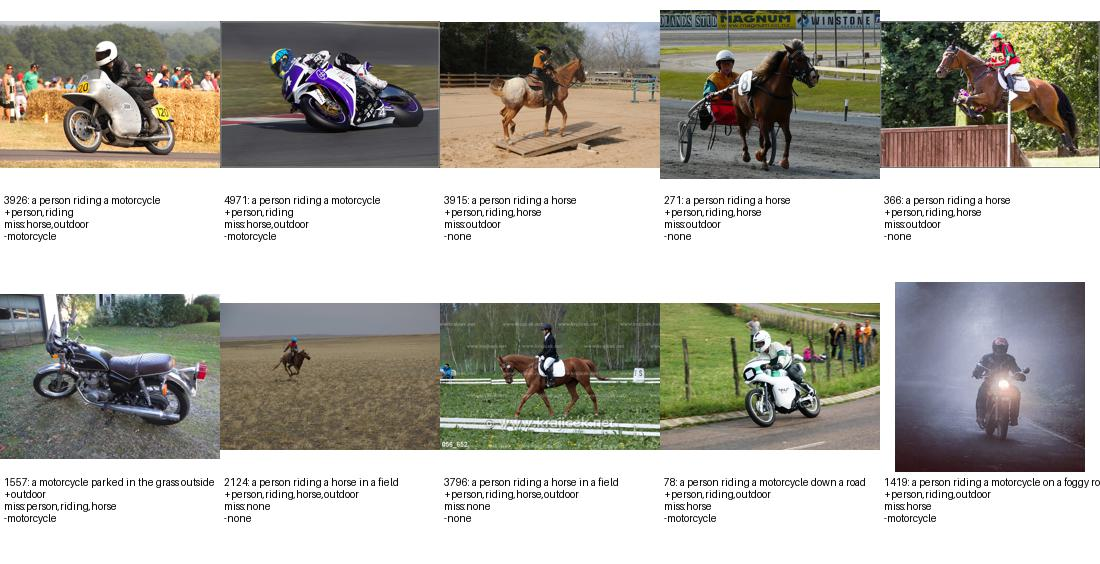

02_raw_hybrid.jpg


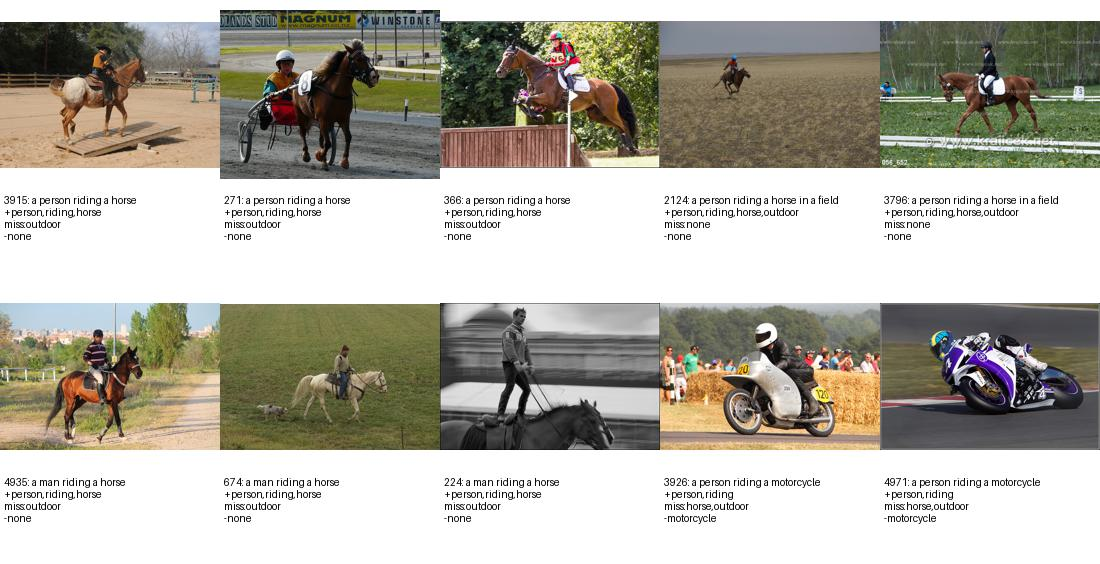

03_constraint_aware_rerank.jpg


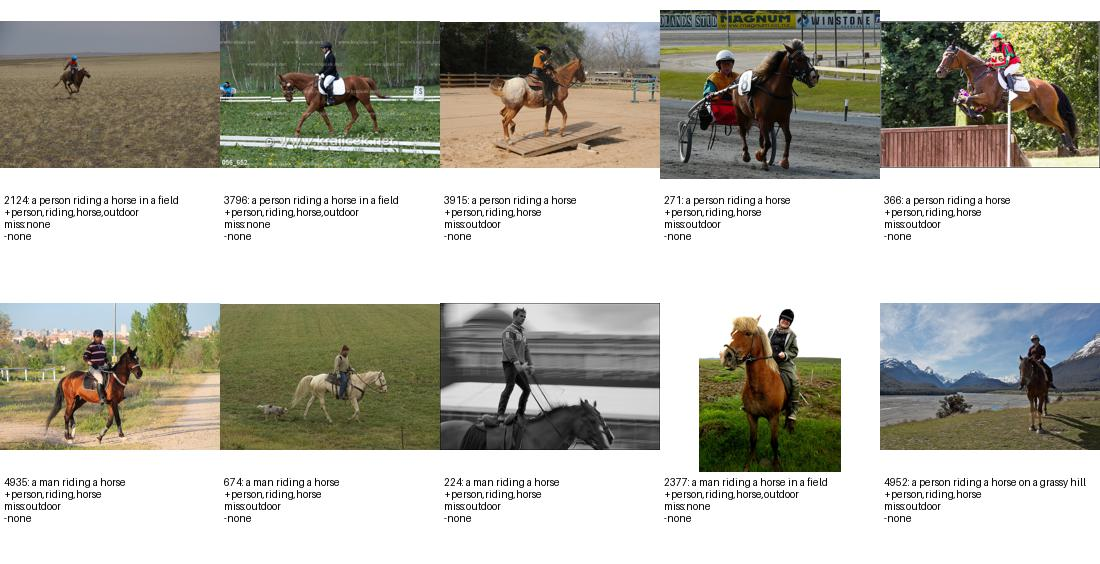

04_hard_negative_filter.jpg


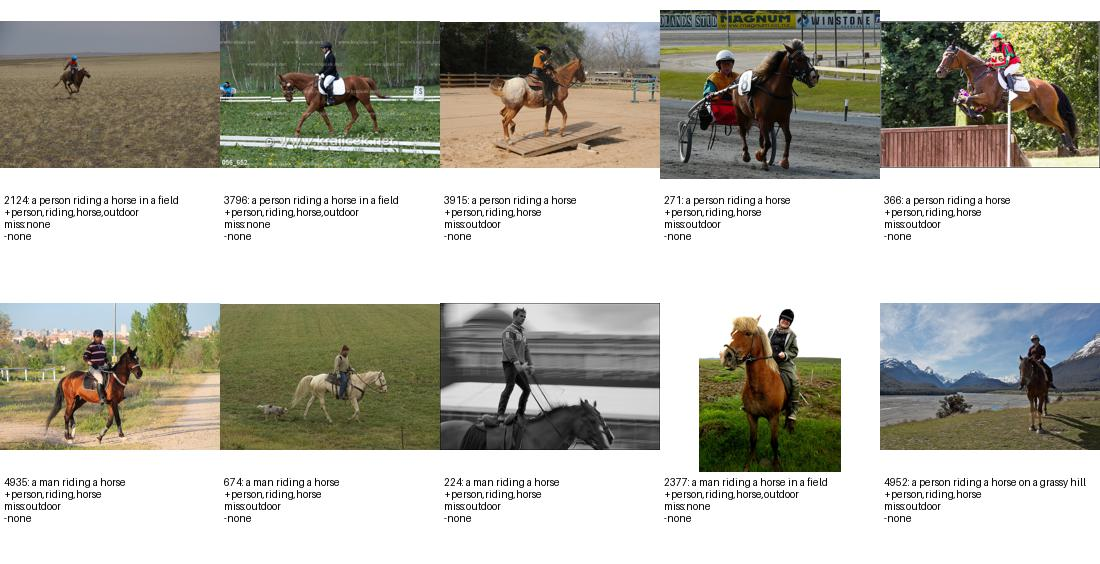

05_rrf_constraint_aware.jpg


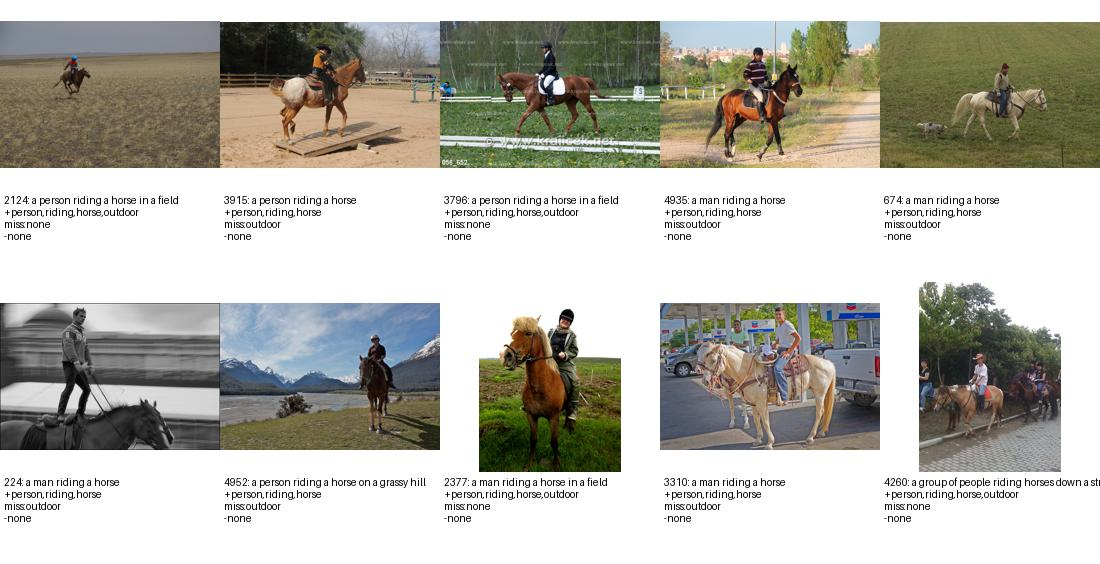

06_contrastive_negative_rerank.jpg


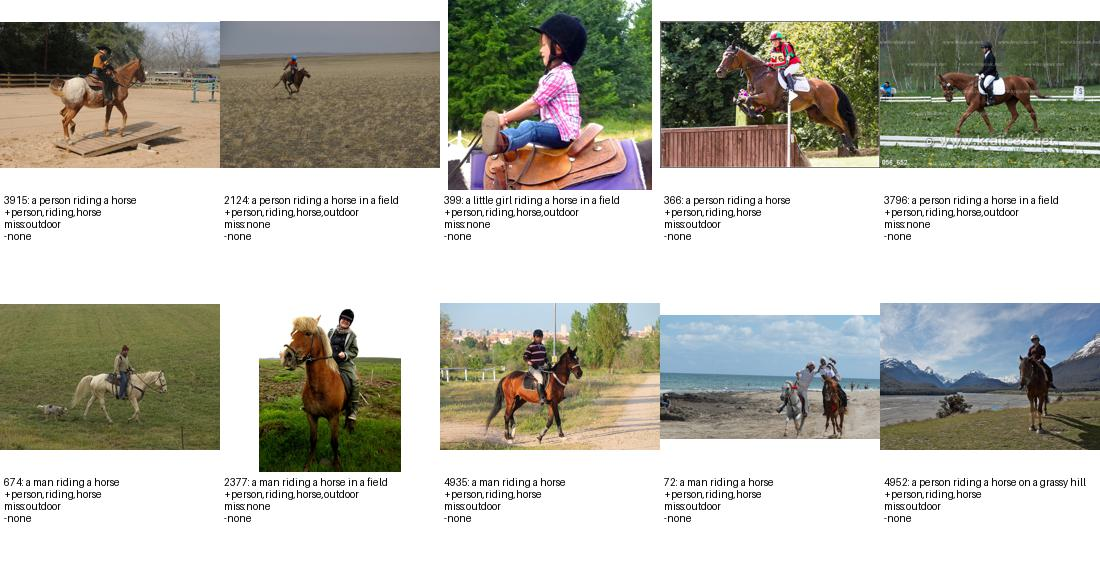

07_openclip_text_to_image.jpg


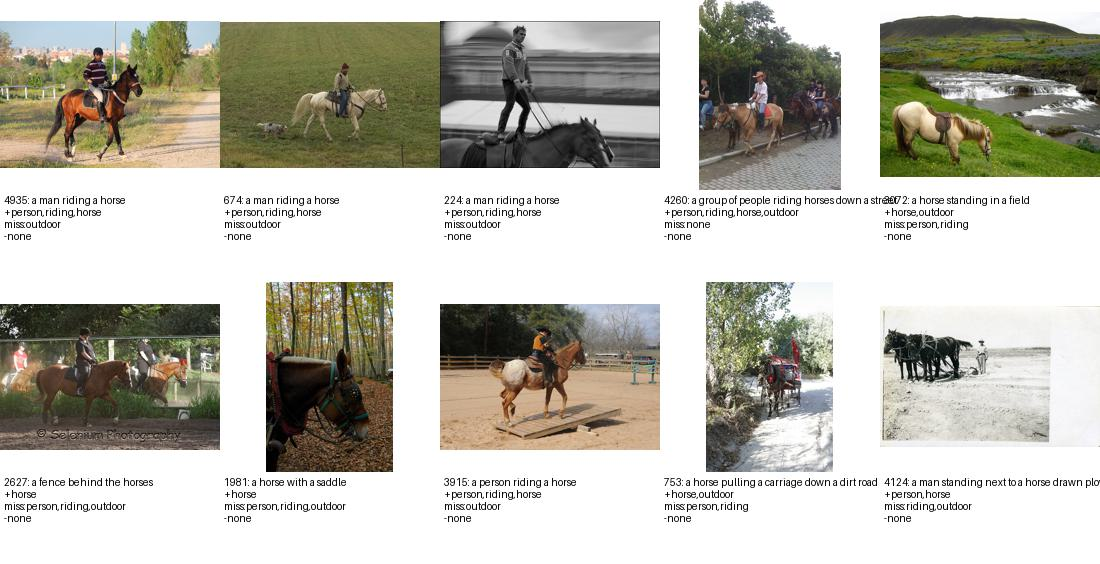

08_openclip_text_to_caption.jpg


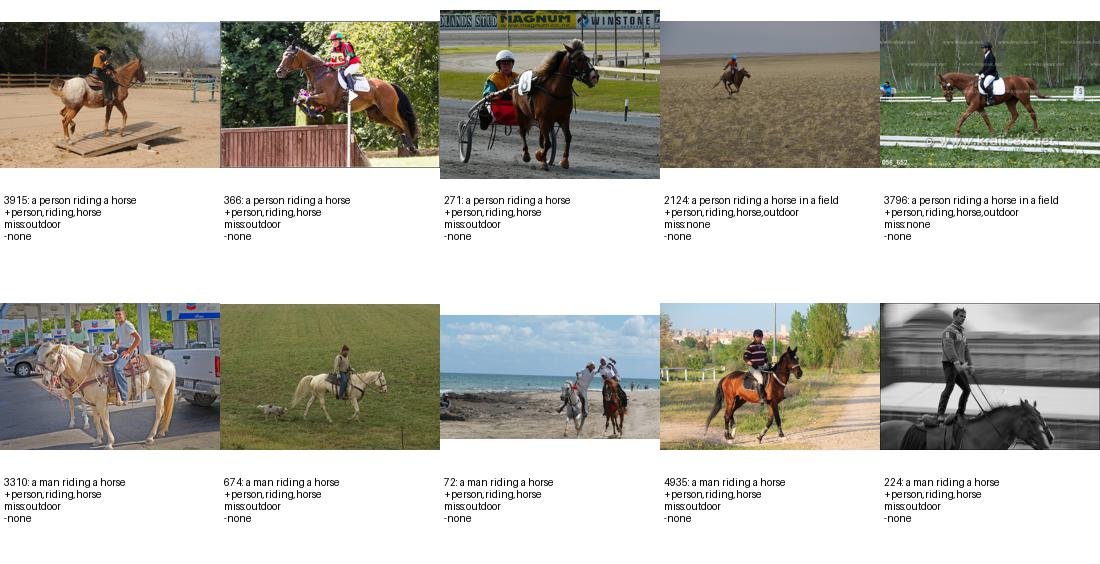

In [12]:
step_dir = REPORT.parent / 'dense_text_to_image' / 'step_by_step' / f'query_{DENSE_QUERY_INDEX + 1:02d}'
for image_path in sorted(step_dir.glob('*.jpg')):
    print(image_path.name)
    display(DisplayImage(filename=str(image_path)))


## Tester des prompts naturels

Ici, tu ne fournis plus `positive` et `negative` a la main. Tu ecris seulement des prompts utilisateur dans `CUSTOM_PROMPTS`, puis le systeme extrait automatiquement les contraintes positives et negatives.

Le tableau d'extraction est volontairement visible: avant de regarder les images, verifie que le systeme a compris le prompt. Si une contrainte extraite est bruit?e ou absente du corpus, les `risk_flags` le signalent dans les cellules suivantes.


In [13]:
from pathlib import Path
import sys
import pandas as pd

ROOT = Path.cwd()
while ROOT.name != 'photo-ai-platform' and ROOT.parent != ROOT:
    ROOT = ROOT.parent
sys.path.append(str(ROOT / 'ml' / 'experiments'))
from artifact_benchmark import (
    DEFAULT_NATURAL_DENSE_QUERY_CASES,
    benchmark_dense_text_to_image,
    encode_text_queries_open_clip,
    load_dataset,
    normalize_dense_case,
)

TEST_LIMIT = 1000  # mets None pour tester les 5000 images

CUSTOM_PROMPTS = [
    *DEFAULT_NATURAL_DENSE_QUERY_CASES[:12],
    'Je veux une image de cuisine avec table et nourriture, mais sans personne visible.',
    'Trouve un animal dans l herbe, plutot un zebre ou une girafe, sans foule autour.',
    'A street photo with a bus and traffic light, but exclude trains and motorcycles.',
    'An indoor living room with a couch, no pets, no people.',
]

CUSTOM_CASES = [normalize_dense_case(prompt) for prompt in CUSTOM_PROMPTS]
constraint_preview = pd.DataFrame([
    {
        'query': case['query'],
        'constraint_source': case['constraint_source'],
        'positive_constraints': ', '.join(case['positive']),
        'negative_constraints': ', '.join(case['negative']),
    }
    for case in CUSTOM_CASES
])
display(constraint_preview)

dataset = load_dataset(
    ROOT / 'notebooks/data/images/val2017',
    ROOT / 'notebooks/data/artifacts',
    limit=TEST_LIMIT,
)
constraint_texts = []
constraint_shapes = []
for case in CUSTOM_CASES:
    positive = list(case['positive'])
    negative = list(case['negative'])
    constraint_shapes.append((len(positive), len(negative)))
    constraint_texts.extend(positive)
    constraint_texts.extend(negative)

all_texts = [case['query'] for case in CUSTOM_CASES] + constraint_texts
all_vectors, encoder_info = encode_text_queries_open_clip(
    all_texts,
    model_name='ViT-L-14',
    pretrained='openai',
    batch_size=8,
)
if all_vectors is None:
    raise RuntimeError(f"OpenCLIP n'a pas renvoye de vecteurs: {encoder_info}")

query_vectors = all_vectors[:len(CUSTOM_CASES)]
constraint_vectors = []
cursor = len(CUSTOM_CASES)
for positive_count, negative_count in constraint_shapes:
    positive_vectors = all_vectors[cursor:cursor + positive_count]
    cursor += positive_count
    negative_vectors = all_vectors[cursor:cursor + negative_count]
    cursor += negative_count
    constraint_vectors.append({'positive': positive_vectors, 'negative': negative_vectors})

custom_report = benchmark_dense_text_to_image(
    dataset,
    CUSTOM_CASES,
    top_k=10,
    query_embeddings=query_vectors,
    constraint_embeddings=constraint_vectors,
)
custom_report['metrics'], custom_report.get('metrics_by_constraint_source')


,query,constraint_source,positive_constraints,negative_constraints
0,I need a clean kitchen or dining table with vi...,inferred,"kitchen, dining, table, food",people
1,"Find a dog relaxing on a sofa indoors, ideally...",inferred,"dog, sitting, sofa, indoor",cat
2,"Show me someone riding a horse outside, avoid ...",inferred,"person, riding, horse, outdoor","car, motorcycle"
3,I want a bus in a city street scene rather tha...,inferred,"bus, city, street","train, station"
4,"Looking for a tennis player on court, not base...",inferred,"tennis, player, court","baseball, skiing"
5,"A small boat on the water, no airplane or trai...",inferred,"boat, water","airplane, train"
6,"Bathroom interior with a sink and mirror, but ...",inferred,"bathroom, indoor, sink, mirror",kitchen
7,"A plate of pizza or food on a table, without p...",inferred,"plate, pizza, food, table",people
8,"Street traffic with cars and a traffic light, ...",inferred,"street, traffic, car, light",animal
9,"A person using skis in the snow, not a snowboard.",inferred,"person, ski, snow",snowboard


c:\Users\choun\miniconda3\envs\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\choun\miniconda3\envs\env\Lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


({'caption_bm25': {'constraint_precision_at_k': 0.6625,
   'false_positive_rate_at_k': 0.2562,
   'avg_positive_coverage_at_k': 0.5561},
  'raw_hybrid': {'constraint_precision_at_k': 0.7125,
   'false_positive_rate_at_k': 0.2188,
   'avg_positive_coverage_at_k': 0.589},
  'constraint_aware_rerank': {'constraint_precision_at_k': 0.9125,
   'false_positive_rate_at_k': 0.0,
   'avg_positive_coverage_at_k': 0.6264},
  'hard_negative_filter': {'constraint_precision_at_k': 0.9125,
   'false_positive_rate_at_k': 0.0,
   'avg_positive_coverage_at_k': 0.6264},
  'rrf_constraint_aware': {'constraint_precision_at_k': 0.8063,
   'false_positive_rate_at_k': 0.0,
   'avg_positive_coverage_at_k': 0.5847},
  'contrastive_negative_rerank': {'constraint_precision_at_k': 0.8313,
   'false_positive_rate_at_k': 0.0,
   'avg_positive_coverage_at_k': 0.5854},
  'openclip_text_to_image': {'constraint_precision_at_k': 0.525,
   'false_positive_rate_at_k': 0.1125,
   'avg_positive_coverage_at_k': 0.474},
  'ope

## Visualiser un prompt personnalise

Choisis un index dans `CUSTOM_PROMPTS`, puis compare les etapes. Les champs importants sont `risk_flags`, `constraint_support`, `missing_positive` et `negative_hits`. Ils montrent pourquoi un prompt dense peut produire de faux positifs ou des resultats seulement partiels.


In [14]:
CUSTOM_CASE_INDEX = 0
CUSTOM_STAGE = 'constraint_aware_rerank'
custom_query = custom_report['queries'][CUSTOM_CASE_INDEX]
custom_stage = next(step for step in custom_query['step_by_step'] if step['stage'] == CUSTOM_STAGE)
{
    'query': custom_query['query'],
    'constraint_source': custom_query.get('constraint_source'),
    'positive_constraints': custom_query['positive_constraints'],
    'negative_constraints': custom_query['negative_constraints'],
    'constraint_support': custom_query.get('constraint_support'),
    'risk_flags': custom_query.get('risk_flags', []),
}


{'query': 'I need a clean kitchen or dining table with visible food, but no people in the shot.',
 'constraint_source': 'inferred',
 'positive_constraints': ['kitchen', 'dining', 'table', 'food'],
 'negative_constraints': ['people'],
 'constraint_support': {'positive': {'kitchen': 23,
   'dining': 0,
   'table': 60,
   'food': 93},
  'negative': {'people': 404}},
 'risk_flags': ['raw_hybrid_contains_explicit_negative_constraints',
  'no_top_result_satisfies_all_caption_constraints',
  'final_results_have_partial_positive_coverage',
  'positive_constraints_without_caption_support']}

In [15]:
pd.DataFrame([
    {
        'stage': step['stage'],
        'negative_hits_in_top_k': step['negative_hits_in_top_k'],
        'complete_constraint_matches': step['complete_constraint_matches'],
        'avg_positive_coverage': step['avg_positive_coverage'],
        **step.get('metrics', {}),
    }
    for step in custom_query['step_by_step']
])


,stage,negative_hits_in_top_k,complete_constraint_matches,avg_positive_coverage,constraint_precision_at_k,false_positive_rate_at_k,avg_positive_coverage_at_k
0,caption_bm25,4,0,0.400,0.5,0.4,0.400
1,raw_hybrid,5,0,0.400,0.4,0.5,0.400
2,constraint_aware_rerank,0,0,0.475,0.9,0.0,0.475
3,hard_negative_filter,0,0,0.475,0.9,0.0,0.475
4,rrf_constraint_aware,0,0,0.325,0.3,0.0,0.325
5,contrastive_negative_rerank,0,0,0.375,0.5,0.0,0.375
6,openclip_text_to_image,0,0,0.250,0.1,0.0,0.250
7,openclip_text_to_caption,0,0,0.225,0.0,0.0,0.225


In [16]:
diagnostic_rows(custom_stage['items'])


,stage,rank,index,filename,caption,positive_hits,missing_positive,negative_hits,blockers,positive_coverage,raw_hybrid,constraint_score,negative_penalty,contrastive_negative_score
0,constraint_aware_rerank,1,345,000000037777.jpg,a kitchen with a table and chairs in it,"kitchen, table","dining, food",,missing_positive_constraints,0.50,0.9317,1.0000,0.0,0.5231
1,constraint_aware_rerank,2,252,000000025986.jpg,a table with a bunch of food on it,"table, food","kitchen, dining",,missing_positive_constraints,0.50,0.8684,0.9451,0.0,0.4275
2,constraint_aware_rerank,3,40,000000003845.jpg,a plate of food on a table,"table, food","kitchen, dining",,missing_positive_constraints,0.50,0.8262,0.9086,0.0,0.4250
3,constraint_aware_rerank,4,976,000000116362.jpg,a bowl of food on a table,"table, food","kitchen, dining",,missing_positive_constraints,0.50,0.8063,0.8914,0.0,0.3349
4,constraint_aware_rerank,5,750,000000088040.jpg,a table with plates of food and glasses of wine,"table, food","kitchen, dining",,missing_positive_constraints,0.50,0.7391,0.8332,0.0,0.3808
5,constraint_aware_rerank,6,789,000000092053.jpg,a table with plates of food and drinks,"table, food","kitchen, dining",,missing_positive_constraints,0.50,0.7118,0.8096,0.0,0.4370
6,constraint_aware_rerank,7,551,000000062554.jpg,a table with plates of food and a bowl of salad,"table, food","kitchen, dining",,missing_positive_constraints,0.50,0.6977,0.7974,0.0,0.4540
7,constraint_aware_rerank,8,583,000000066706.jpg,a table with a plate of food and a cup of coffee,"table, food","kitchen, dining",,missing_positive_constraints,0.50,0.6820,0.7838,0.0,0.3333
8,constraint_aware_rerank,9,75,000000007574.jpg,a kitchen with a sink and a refrigerator,kitchen,"dining, table, food",,missing_positive_constraints,0.25,0.7744,0.7387,0.0,0.3806
9,constraint_aware_rerank,10,120,000000012576.jpg,a pizza on a table,"table, food","kitchen, dining",,missing_positive_constraints,0.50,0.6142,0.7251,0.0,0.2835


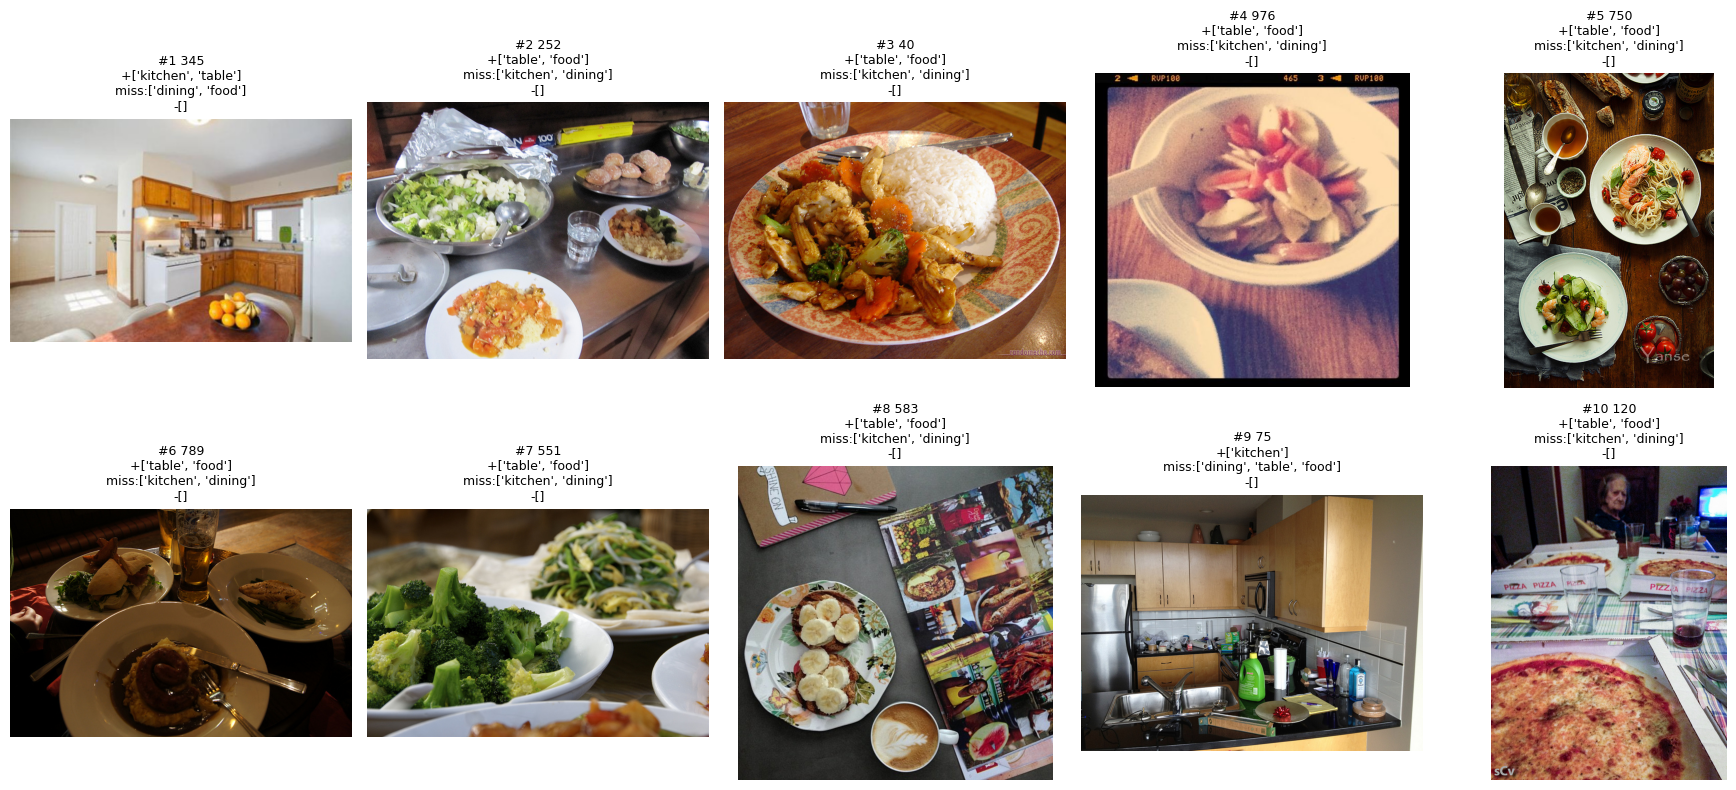

In [17]:
import matplotlib.pyplot as plt
from PIL import Image

items = custom_stage['items'][:10]
cols = 5
rows = (len(items) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(18, 4 * rows))
axes = axes.ravel() if len(items) > 1 else [axes]
for ax, item in zip(axes, items):
    image = Image.open(item['path']).convert('RGB')
    ax.imshow(image)
    diag = item['diagnostics']
    title = f"#{item['rank']} {item['index']}\n+{diag['positive_hits']}\nmiss:{diag['missing_positive']}\n-{diag['negative_hits']}"
    ax.set_title(title, fontsize=9)
    ax.axis('off')
for ax in axes[len(items):]:
    ax.axis('off')
plt.tight_layout()
plt.show()


In [18]:
case_index = 0
method = 'constraint_aware_rerank'
custom_report['queries'][case_index]['method_metrics'][method], custom_report['queries'][case_index]['methods'][method]


({'constraint_precision_at_k': 0.9,
  'false_positive_rate_at_k': 0.0,
  'avg_positive_coverage_at_k': 0.475},
 [{'index': 345,
   'path': 'c:\\Users\\choun\\OneDrive - Groupe INSEEC (POCE)\\Bureau\\projet-ia\\photo-ai-platform\\notebooks\\data\\images\\val2017\\000000037777.jpg',
   'filename': '000000037777.jpg',
   'caption': 'a kitchen with a table and chairs in it',
   'rank': 1,
   'stage': 'constraint_aware_rerank',
   'diagnostics': {'positive_hits': ['kitchen', 'table'],
    'missing_positive': ['dining', 'food'],
    'negative_hits': [],
    'positive_coverage': 0.5,
    'negative_hit_count': 0,
    'blockers': ['missing_positive_constraints']},
   'scores': {'bm25': 7.343,
    'tfidf': 0.3349,
    'raw_hybrid': 0.9317,
    'positive_coverage': 0.5,
    'negative_penalty': 0.0,
    'constraint_score': 1.0,
    'hard_filter_score': 1.0,
    'rrf_constraint_score': 1.0,
    'openclip_text_to_image': 0.2415,
    'openclip_text_to_caption': 0.7519,
    'contrastive_negative_score

## Visualiser les resultats

Les planches sont generees dans `reports/algorithm_tests/latest/text_to_image/`. Ouvrir en priorite:

- `caption_bm25/`
- `openclip_text_to_image/`
- `openclip_text_to_caption/`
- `rrf_all_channels/`
- `two_stage_bm25_recall_openclip_rerank/`
- `../dense_text_to_image/constraint_aware_rerank/`
- `../dense_text_to_image/hard_negative_filter/`
- `../dense_text_to_image/contrastive_negative_rerank/`

Attention: la metrique automatique est derivee des captions, donc elle favorise BM25. La validation produit doit combiner cette metrique avec une revue visuelle.

## Lecture produit

La meilleure base production est l'hybride separe par canaux. BM25 donne une baseline tres solide quand les captions sont bonnes. OpenCLIP text->image est moins fort sur la metrique caption, mais il reste indispensable pour retrouver des concepts visuels qui ne sont pas bien lexicalises.

Le point important: on ne moyenne pas les embeddings de plusieurs intentions. Quand on etend une requete avec des seeds, le notebook garde les vecteurs separes et prend le meilleur signal par canal.